<img src="http://www.cidaen.es/assets/img/mCIDaeNnb.png" alt="Logo CiDAEN" align="right">




<br><br><br>
<h2><font color="#00586D" size=4>Módulo 13: Almacenes de datos: Datalakes</font></h2>



<h1><font color="#00586D" size=5>Capstone XIII - Orquestación de ETLs en un Datalake</font></h1>

<br><br><br>
<div style="text-align: right">
<font color="#00586D" size=3>Javier Cózar</font><br>
<font color="#00586D" size=3>Máster en Ciencia de Datos e Ingeniería de Datos en la Nube</font><br>
<font color="#00586D" size=3>Universidad de Castilla-La Mancha</font>

</div>

## NobelPrice

En este capstone vamos a trabajar con los datos de las celebraciones de premios Nobel y las personas y entidades laureadas. Para ello haremos uso de la API de [nobelprize.org](https://www.nobelprize.org/about/developer-zone-2/). Esta API tiene documentación en formato OpenAPI alojado en la plataforma [swaggerhub](https://app.swaggerhub.com/apis/NobelMedia/NobelMasterData/2.1), que es un estandar bastante extendido y como podréis comprobar es muy cómodo e interesante de explorar!

Vamos a crear un datalake usando **AWS S3**, a implementar nuestras ETLs en **AWS Lambda**, y a orquestar su ejecución a través de **Prefect**, ejecutando el flujo localmente. A continuación describimos qué ETLs implementar y los pasos a seguir para orquestar las ETLs con Prefect.


### Descripción

Los premios Nobel se celebran anualmente (salvo algún problema, como ocurrió durante _la segunda guerra mundial_). Vamos a automatizar la extracción de los datos todos los **1 de enero de cada año** haciendo lo siguiente:
- Descargaremos los datos **del año anterior para todas las categorías** (`che`, `eco`, `lit`, `pea`, `phy`, `med`)
- Almacenaremos en el datalake (prefijo `raw`) estos datos en formato parquet
- Ejecutaremos las ETL implementadas (bronze y silver)

Finalmente, usaremos la libreta de jupyter para acceder a las tablas generadas por la ETL y **responder ciertas preguntas de analítica**.

### AWS provided lambda layer

A lo largo del capstone se desplegarán funciones AWS Lambda con capacidad de ejecutar el código implementado. Para que la lambda tenga disponible los paquetes de python necesarios (pandas, pyarrow, requests y awswrangler) usaremos la aws provided lambda layer llamada `AWSSDKPandas-Python312` para Python 3.12 (version 16) que tiene las siguientes versiones de las librerías:

```
pandas==2.2.3
pyarrow==18.1.0
requests==2.32.0
awswrangler==3.11.0
```

Para trabajar en local, crea un entorno virtual y trabaja con estos paquetes especificados en el fichero `requirements_lambda.txt` para que el código desarrollado funcione igual localmente que en la AWS Lambda.

In [1]:
from dotenv import load_dotenv
load_dotenv()




True

In [2]:
import boto3

s3 = boto3.client("s3")
response = s3.list_buckets()
buckets = [b["Name"] for b in response["Buckets"]]
print("Buckets en mi cuenta:", buckets)


Buckets en mi cuenta: ['capstone.13.luis', 'cidaen-capstone-12-1', 'es.cidaen.m12.dataframes.luis.2']


## Ejercicio 1. Crear el bucket de S3 que será nuestro datalake

Vamos a crear un bucket de S3 en nuestra cuenta de AWS Academy. Este bucket contendrá los prefijos:

- **raw**: contendrá los datos en crudo extraídos de la API.
- **bronze**: contendrá tablas que serán uniones de tablas con nombres de columnas posiblemente modificadas y tipos de columnas casteadas.
- **silver**: contendrá tablas de alto nivel que serán utilizadas para acceder a la información granularmente.

## Ejercicio 2. Crear las AWS Lambdas de extracción

Las funciones deben extraer información de `nobelPrizes` y `laureates`, es decir, premios Nobel y laureados o personas premiadas. Para ello:

1. Usar el endpoint `http://api.nobelprize.org/2.1/nobelPrize/{category}/{year}` para obtener la información de todos los premios Nobel para una categoría y un año concreto.
2. Usar el endpoint `http://api.nobelprize.org/2.1/laureate/{laureateID}` para obtener la información de un laureado en base a su ID.

Los datos serán almacenados en el datalake en formato parquet, que permite leer cómodamente varios ficheros con una llamada `pd.read_parquet` y podríamos ejecutar procesos de compactación de datos cuando fuese necesario. Sin embargo, hay ciertas estructuras complejas que parquet no tiene implementado en su versión en python (algunas de ellas nos las encontramos en las respuestas de estas APIs). Por ello, en lugar de almacenar los datos directamente en crudo los procesaremos ligeramente con el fin de generar datos estructurados. Es importante destacar que esto se realiza **para simplificar el proceso**, ya que es importante almacenar los datos en crudo, tal cual los extraemos, para su posterior uso. Una práctica más realista sería almacenar el json tal cual como raw, y usar una lambda para crear un raw_processed que sería el parquet que estamos generando ahora.

**Importante**: selecciona la arquitectura `x86_64` y la versión de python 3.12. Finalmente, debes seleccionar el **rol de Iam** existente llamado `LabRole`. También configuraremos el timeout de la lambda a 1 minuto y 2048 MB de RAM para asegurarnos que le da tiempo a ejecutarse correctamente.

### Ejercicio 3.1 AWS Lambda `extractNobelPrizes`

La función debe recibir en el evento la categoría y el año a extraer y hacer uso del endpoint `http://api.nobelprize.org/2.1/nobelPrize/{category}/{year}` para extraer la información. Una vez obtenido, vamos a construir un DataFrame con pandas de una sola fila (manualmente a partir de una estructura de python). Este dataframe tendrá las siguientes columnas:

- **awardYear**: el campo `awardYear`. Si no existe dejar un NA
- **category**: el campo `en` dentro de `category`. Si no existe dejar un NA
- **categoryFullName**: el campo `en` dentro de `categoryFullName`. Si no existe dejar un NA
- **dateAwarded**: el campo `dateAwarded`. Si no existe dejar un NA
- **prizeAmount**: el campo `prizeAmount`. Si no existe dejar un NA
- **prizeAmountAdjusted**: el campo `prizeAmountAdjusted`. Si no existe dejar un NA
- **laureates_id**: una lista de laureate id's, correspondiente con el campo `id` de cada elemento de la lista de `laureates`
- **laureates_portion**: una lista de strings correspondientes con el valor interno `portion` de cada elemento de la lista de `laureates`

Posteriormente vamos a almacenar el DataFrame en el bucket del datalake en formato parquet (con el nombre `raw/nobelPrizes/{category}-{year}.parquet`).

Además la función debe **devolver una lista que contenaga los IDs de los laureados** implicados en los premios Nobel obtenidos (lista de id's de la columna `laureates`).

Puedes ver si la lambda funciona usando uno de los siguientes códigos como categoría `che`, `eco`, `lit`, `pea`, `phy`, `med` y un año a tu elección (por ejemplo 2010).

In [ ]:
import os
import json
import requests
import pandas as pd
import awswrangler as wr

def lambda_handler(event, context):

    category = event["category"]
    year = event["year"]


    url = f"http://api.nobelprize.org/2.1/nobelPrize/{category}/{year}"
    resp = requests.get(url)
    data = resp.json()


    if isinstance(data, dict):
        nobel_data = data.get("nobelPrizes", [])
    elif isinstance(data, list):
        nobel_data = data
    else:
        nobel_data = []

    if not nobel_data:
        return {
            "message": "No prizes found for this category/year",
            "laureates_id": []
        }

    prize = nobel_data[0]

 
    awardYear = prize.get("awardYear", None)
    category_en = prize.get("category", {}).get("en", None)
    categoryFullName_en = prize.get("categoryFullName", {}).get("en", None)
    dateAwarded = prize.get("dateAwarded", None)
    prizeAmount = prize.get("prizeAmount", None)
    prizeAmountAdjusted = prize.get("prizeAmountAdjusted", None)


    laureates = prize.get("laureates", [])
    laureates_id = [l.get("id", None) for l in laureates]
    laureates_portion = [l.get("portion", None) for l in laureates]


    df = pd.DataFrame([{
        "awardYear": awardYear,
        "category": category_en,
        "categoryFullName": categoryFullName_en,
        "dateAwarded": dateAwarded,
        "prizeAmount": prizeAmount,
        "prizeAmountAdjusted": prizeAmountAdjusted,
        "laureates_id": laureates_id,
        "laureates_portion": laureates_portion,
    }])


    bucket = os.environ.get("BUCKET_NAME", "capstone.13.luis")
    parquet_path = f"s3://{bucket}/raw/nobelPrizes/{category}-{year}.parquet"


    wr.s3.to_parquet(df, parquet_path, index=False)

  
    return {
        "message": f"Datos guardados en {parquet_path}",
        "laureates_id": laureates_id
    }


### Ejercicio 3.2 AWS Lambda `extractLaureate`

La función debe recibir en el evento el ID del laureado a extraer y hacer uso del endpoint `http://api.nobelprize.org/2.1/laureate/{laureateID}` para extraer la información. Una vez obtenido, vamos a construir un DataFrame con pandas de una sola fila (manualmente a partir de una estructura de python). Este dataframe tendrá las siguientes columnas:

- **id**: el campo `id`. Si no existe dejar un NA
- **fullName**: el campo `en` dentro de `fullName`. Si no existe dejar un NA
- **fileName**: el campo `fileName`. Si no existe dejar un NA
- **gender**: el campo `gender`. Si no existe dejar un NA
- **birth**: el campo `date` dentro de `birth`. Si no existe dejar un NA

Posteriormente vamos a almacenar el DataFrame en el bucket del datalake en formato parquet (con el nombre `raw/laureates/{laureateID}.parquet`).

Puedes ver si la lambda funciona usando uno de los id's de la llamada anterior (por ejemplo 851).

**Importante**: selecciona la arquitectura `x86_64` y la versión de python 3.12. Finalmente, debes seleccionar el **rol de Iam** existente llamado `LabRole`. También configuraremos el timeout de la lambda a 1 minuto y 2048 MB de RAM para asegurarnos que le da tiempo a ejecutarse correctamente.

In [ ]:
import os
import requests
import pandas as pd
import awswrangler as wr

def lambda_handler(event, context):

    laureate_id = event["laureateID"]


    url = f"http://api.nobelprize.org/2.1/laureate/{laureate_id}"
    resp = requests.get(url)
    data = resp.json()


    if isinstance(data, dict):
        laureates = data.get("laureates", [])
    elif isinstance(data, list):
        laureates = data
    else:
        laureates = []

    if not laureates:
        return {
            "message": "No laureate found for this ID.",
            "laureate_id": laureate_id
        }

    laureate = laureates[0]


    id_ = laureate.get("id", None)
    fullName = laureate.get("fullName", {}).get("en", None)
    fileName = laureate.get("fileName", None)
    gender = laureate.get("gender", None)
    birth = laureate.get("birth", {}).get("date", None)

   
    df = pd.DataFrame([{
        "id": id_,
        "fullName": fullName,
        "fileName": fileName,
        "gender": gender,
        "birth": birth,
    }])


    bucket = os.environ.get("BUCKET_NAME", "capstone.13.luis")
    parquet_path = f"s3://{bucket}/raw/laureates/{laureate_id}.parquet"


    wr.s3.to_parquet(df, parquet_path, index=False)

    return {
        "message": f"Laureado {laureate_id} guardado en {parquet_path}",
        "laureate_id": laureate_id
    }


In [5]:
parquet_path = f"s3://capstone.13.luis/raw/laureates/851.parquet"

df = wr.s3.read_parquet(parquet_path)
df

,id,fullName,fileName,gender,birth
0,851,Richard F. Heck,heck,male,1931-08-15


## Combinación de premios Nobel y laureados

Como los datos en `raw/nobelPrizes` y `raw/laureates` son ficheros parquet, podemos leer todos de una y crear un único `pd.DataFrame` usando `pd.read_parquet("s3://{bucket-datalake}/raw/nobelPrizes")` y `pd.read_parquet("s3://{bucket-datalake}/raw/laureates")` respectivamente.

A continuación vamos a implementar dos funciones AWS Lambda para generar una tabla `bronze` y una tabla `silver`.

**NOTA**: Para desarrollar localmente el código de estas dos ETL podéis usar los ficheros `nobelPrizes-1901-2019.parquet` y `laureates-1901-2019.parquet` disponibles en campus virtual, que contienen los datos exportados desde 1901 hasta 2019 (usando los endpoints de la API que dan todos los datos existentes paginados). Pero recordad que la lambda debe leer finalmente directamente del bucket de S3. En adelante nos referiremos a los datos de nobel prizes como `df_nobel_prizes` y a los datos de laureates como `df_laureates`.

## Ejercicio 4. ETL bronze

En esta ETL vamos a analizar los datos en crudo que tenemos delante, limpiarlos, reestructurarlos y combinarlos.

### Procesar el dataframe `df_nobel_prizes`

1. Vamos a explorar el contenido del dataframe y la completitud de los datos. ¿Hay nobels sin asignar? (es decir, `laureates` con valores perdidos). **Descartaremos esas filas en las que hay nobeks sin asignar**.
2. Un mismo premio puede ser compartido por varios laureados, esto se indica a través de las columnas `laureates_id` y `laureates_portion`, que son listas. Utilizar [explode](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html) para transformar el dataframe y tener un solo laureado por fila.
3. Vamos a castear la columna `laureates_id` para que sea un valor entero

### Procesar el dataframe `df_laureates`

4. Hemos detectado que alguna de las columnas de interés no tiene un nombrado consistente. Renombrar las columnas:
    - `fileName` por `file_name`
5. Vamos a castear la columna `id` para que sea un valor entero

### Combinar ambos dataframes

6. Combinar ambos dataframes por medio de la columna del id del laureado. Usar un inner join.

### Implementar la AWS Lambda que ejecute la ETL bronze

7. La lambda debe y genere en el datalake un fichero parquet resultante de escribir el dataframe de pandas (path `bronze/bronze_laureates.parquet`).
8. Al igual que antes utiliza la layer. Selecciona la arquitectura `x86_64` y la versión de python 3.12. Finalmente, debes seleccionar el **rol de Iam** existente llamado `LabRole`. También configuraremos el timeout de la lambda a 5 minutos y 2048 MB de RAM para asegurarnos que le da tiempo a ejecutarse correctamente.


**Nota**: el resultado de aplicar la ETL debería ser similar al que mostramos a continuación.

|    |   awardYear | category   | categoryFullName             | dateAwarded   |   prizeAmount |   prizeAmountAdjusted |   laureates_id | laureates_portion   | fullName        | fileName   | gender   | birth      |
|---:|------------:|:-----------|:-----------------------------|:--------------|--------------:|----------------------:|---------------:|:--------------------|:----------------|:-----------|:---------|:-----------|
|  0 |        2010 | Chemistry  | The Nobel Prize in Chemistry | 2010-10-06    |      10000000 |              11015580 |            851 | 1/3                 | Richard F. Heck | heck       | male     | 1931-08-15 |
|  1 |        2010 | Chemistry  | The Nobel Prize in Chemistry | 2010-10-06    |      10000000 |              11015580 |            851 | 1/3                 | Richard F. Heck | heck       | male     | 1931-08-15 |

In [ ]:
import os
import pandas as pd
import awswrangler as wr
import numpy as np

def is_valid_laureates(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return False
    if isinstance(x, list) or isinstance(x, np.ndarray):
        return len(x) > 0 and all(pd.notnull(i) for i in x)
    return False

def lambda_handler(event, context):
   
    bucket = os.environ.get("BUCKET_NAME", "capstone.13.luis")
    path_nobel = f"s3://{bucket}/raw/nobelPrizes/"
    path_laureates = f"s3://{bucket}/raw/laureates/"

  
    df_nobel = wr.s3.read_parquet(path_nobel)
    df_laureates = wr.s3.read_parquet(path_laureates)


 
    df_nobel = df_nobel[df_nobel["laureates_id"].apply(is_valid_laureates)]


    df_nobel = df_nobel.explode(["laureates_id", "laureates_portion"]).reset_index(drop=True)

 
    df_nobel["laureates_id"] = df_nobel["laureates_id"].astype(int)


    df_laureates = df_laureates.rename(columns={"fileName": "file_name"})
    df_laureates["id"] = df_laureates["id"].astype(int)


    df_bronze = pd.merge(
        df_nobel,
        df_laureates,
        left_on="laureates_id",
        right_on="id",
        how="inner"
    )


    columnas = [
        "awardYear", "category", "categoryFullName", "dateAwarded",
        "prizeAmount", "prizeAmountAdjusted", "laureates_id", "laureates_portion",
        "fullName", "file_name", "gender", "birth"
    ]
    df_bronze = df_bronze[columnas]


    bronze_path = f"s3://{bucket}/bronze/bronze_laureates.parquet"
    wr.s3.to_parquet(df_bronze, bronze_path, index=False)

    return {
        "message": f"ETL bronze completada. Guardado en {bronze_path}",
        "rowcount": len(df_bronze)
    }


Archivo guardado en data/bronze_laureates.parquet


,awardYear,category,categoryFullName,dateAwarded,prizeAmount,prizeAmountAdjusted,laureates_id,laureates_portion,fullName,file_name,gender,birth
0,1901,Chemistry,The Nobel Prize in Chemistry,1901-11-12,150782,9704878,160,1,Jacobus Henricus van 't Hoff,hoff,male,1852-08-30
1,1901,Literature,The Nobel Prize in Literature,1901-11-14,150782,9704878,569,1,Sully Prudhomme,prudhomme,male,1839-03-16
2,1901,Peace,The Nobel Peace Prize,1901-12-10,150782,9704878,462,1/2,Jean Henry Dunant,dunant,male,1828-05-08
3,1901,Peace,The Nobel Peace Prize,1901-12-10,150782,9704878,463,1/2,Frédéric Passy,passy,male,1822-05-20
4,1901,Physics,The Nobel Prize in Physics,1901-11-12,150782,9704878,1,1,Wilhelm Conrad Röntgen,rontgen,male,1845-03-27


## Ejercicio 5. ETL silver

En esta ETL vamos a procesar el dataframe bronze `df_bronze_laureates` y a construir nuevas variables.

### Procesar el dataframe `df_bronze_laureates`


1. Tras analizar el dataframe bronze hemos evaluado el nombre de las columnas y algunas de ellas no nos parece un nombrado consistente. Renombrar las columnas para que tengan un formato uniforme:
    - `prizeAmount` por `prize_amount`
    - `awardYear` por `year`
    - `fileName` por `file_name`
    - `laureates_id` por `laureate_id`
    - `laureates_portion` por `laureate_portion`
    - `categoryFullName` por `category_full_name`
    - `dateAwarded` por `date_awarded`
    - `prizeAmountAdjusted` port `prize_amount_adjusted`
    - `fullName` por `full_name`
 
2. Una de las columnas que hemos creado anteriormente, `laureate_portion`, es un string que representa una fracción. Nos interesa disponer del valor en formato numérico para crear una nueva columna `prize_amount_real` que represente el premio real recibido por cada laureado (al repartir el premio se divide económicamente en base a `laureate_portion`). Vamos a crear dos columnas más:

  - `laureate_portion`: Vamos a sobreescribir esta columna, que es una fracción en formato string, para que sea un número decimal. Usar el código `from fractions import Fraction`, y aplicar un casting a `float` del `Fraction(texto)` para convertirlo a valor numérico

```python
from fractions import Fraction
float(Fraction("1/3"))
```

  - `prize_amount_real`: Esta columna representa el valor real ganado por cada laureado. Se calcula como `prize_amount` multiplicado por `laureate_portion`
  
### Implementar la AWS Lambda que ejecute la ETL silver

3. La lambda debe y genere en el datalake un fichero parquet resultante de escribir el dataframe de pandas (path `silver/silver_laureates.parquet`).
4. Al igual que antes utiliza la layer. Selecciona la arquitectura `x86_64` y la versión de python 3.12. Finalmente, debes seleccionar el **rol de Iam** existente llamado `LabRole`. También configuraremos el timeout de la lambda a 5 minutos y 2048 MB de RAM para asegurarnos que le da tiempo a ejecutarse correctamente.


**Nota**: el resultado de aplicar la ETL debería ser similar al que mostramos a continuación.

|    |   year | category   | categoryFullName             | dateAwarded   |   prize_amount |   prizeAmountAdjusted |   laureate_id |   laureate_portion | fullName        | file_name   | gender   | birth      |   prize_amount_real |
|---:|-------:|:-----------|:-----------------------------|:--------------|---------------:|----------------------:|--------------:|-------------------:|:----------------|:------------|:---------|:-----------|--------------------:|
|  0 |   2010 | Chemistry  | The Nobel Prize in Chemistry | 2010-10-06    |       10000000 |              11015580 |           851 |           0.333333 | Richard F. Heck | heck        | male     | 1931-08-15 |         3.33333e+06 |
|  1 |   2010 | Chemistry  | The Nobel Prize in Chemistry | 2010-10-06    |       10000000 |              11015580 |           851 |           0.333333 | Richard F. Heck | heck        | male     | 1931-08-15 |         3.33333e+06 |

In [ ]:
import os
import pandas as pd
import awswrangler as wr
from fractions import Fraction

def lambda_handler(event, context):
    
    bucket = os.environ.get("BUCKET_NAME", "capstone.13.luis")
    bronze_path = f"s3://{bucket}/bronze/bronze_laureates.parquet"
    silver_path = f"s3://{bucket}/silver/silver_laureates.parquet"


    df = wr.s3.read_parquet(bronze_path)


    rename_dict = {
        "awardYear": "year",
        "categoryFullName": "category_full_name",
        "dateAwarded": "date_awarded",
        "prizeAmount": "prize_amount",
        "prizeAmountAdjusted": "prize_amount_adjusted",
        "laureates_id": "laureate_id",
        "laureates_portion": "laureate_portion",
        "fullName": "full_name",
        "fileName": "file_name"
    }
    df = df.rename(columns=rename_dict)


    def safe_fraction_to_float(x):
        try:
            return float(Fraction(str(x)))
        except Exception:
            return None

    df["laureate_portion"] = df["laureate_portion"].apply(safe_fraction_to_float)
    df["prize_amount_real"] = df["prize_amount"] * df["laureate_portion"]


    wr.s3.to_parquet(df, silver_path, index=False)

    return {
        "message": f"ETL silver completada. Guardado en {silver_path}",
        "rowcount": len(df)
    }


Archivo guardado en data/silver_laureates.parquet
   year    category             category_full_name date_awarded  prize_amount  \
0  1901   Chemistry   The Nobel Prize in Chemistry   1901-11-12        150782   
1  1901  Literature  The Nobel Prize in Literature   1901-11-14        150782   
2  1901       Peace          The Nobel Peace Prize   1901-12-10        150782   
3  1901       Peace          The Nobel Peace Prize   1901-12-10        150782   
4  1901     Physics     The Nobel Prize in Physics   1901-11-12        150782   

   prize_amount_adjusted  laureate_id  laureate_portion  \
0                9704878          160               1.0   
1                9704878          569               1.0   
2                9704878          462               0.5   
3                9704878          463               0.5   
4                9704878            1               1.0   

                      full_name  file_name gender       birth  \
0  Jacobus Henricus van 't Hoff       hoff 

## Ejercicio 6. Orquestar con prefect core

Ahora vamos a escribir un flujo con prefect para que:

1. Exporte los datos del año anterior invocando la lambda `extractNobelPrizes` con lun parámetro indicando la categoría a exportar (`che`, `eco`, `lit`, `pea`, `phy` o `med`). Es decir, se realizarán 6 invocaciones, una por categoría. Para obtener en el año anterior obtendremos del contexto la fecha actual (`prefect.runtime.flow_run.scheduled_start_time.year`), que es un objeto `pendulum.datetime.DateTime`, accederemos al campo `year` y le restaremos 1.
2. Por cada invocación de la lambda `extractNobelPrizes` se realizarán `N` invocaciones de la lambda `extractLaureate`, usando la funcionalidad de `map` para que por cada id de laureado devuelto por la lambda `extractNobelPrizes` (lista de ids de laureados) se ejecute la lambda `extractLaureate` con el parámetro `laureateId `correspondiente.
3. Tras extraer todos los datos del año anterior, ahora deberemos ejecutar la ETL bronze (lambda `bronze_laureates`).
4. Finalmente, deberemos ejecutar la ETL bronze (lambda `bronze_laureates`).

**Nota**: para invocar las AWS Lambda usaremos boto3. Podemos ver la documentación en este [link](https://boto3.amazonaws.com/v1/documentation/api/latest/reference/services/lambda.html#Lambda.Client.invoke).

**Tip**: recuerda que puedes ejecutar tareas de prefect accediendo al atributo `fn` y los flujos ejecutándolos como si fueran funciones. Si necesitas establecer un contexto específico, como es el caso de la tarea `extract_nobel_prizes` con respecto a la fecha actual, puedes usar variables de entorno tal y como se indica en la [documentación oficial](https://docs.prefect.io/v3/develop/runtime-context#access-runtime-context). Para no tener que usar monkeypatch, usaremos una variable auxiliar:

```python
import os
os.environ["PREFECT__RUNTIME__FLOW_RUN__MOCKED_SCHEDULED_START_TIME"] = "2020-01-01 00:00:00"
# si queremos deshacer el cambio, basta con borrar esta variable de entorno
# del os.environ["PREFECT__RUNTIME__FLOW_RUN__MOCKED_SCHEDULED_START_TIME"] 
```

En este caso el elemento `prefect.runtime.flow_run.scheduled_start_time` será un string. Podemos usar el siguiente código en nuestra tarea de `extract_nobel_prizes` para que si estamos mockeando el valor de `scheduled_start_time` y es un string convertirlo a `DateTime`, y si no dejarlo como está:

```python
try:
    print(prefect.runtime.flow_run.mocked_scheduled_start_time)
    year = datetime.datetime.strptime(prefect.runtime.flow_run.mocked_scheduled_start_time, "%Y-%m-%d %H:%M:%S").year
except:
    year = prefect.runtime.flow_run.scheduled_start_time.year
```

## Ejercicio 7. Backfill

La forma ideal de exportar todos los datos desde 1901 hasta la fecha no es ejecutar nuestro flujo para cada año simulando su ejecución normal año a año, ya que supondría muchas llamadas API y sería un proceso muy lento y costoso. Lo ideal es hacer uso de los endpoints de la API para obtener todos los datos en bloque y hacer ese proceso de captura de los datos en bloque una sola vez, y a partir de ahí ya se encargaría nuestro flujo de actualizar los datos año a año, así como de ejecutar las ETLs correspondientes.

Los ficheros `nobelPrizes-1901-2019.parquet` y `laureates-1901-2019.parquet` (en el fichero `data.zip`) disponibles en campus virtual contienen los datos exportados desde 1901 hasta 2019 usando los endpoints de la API que dan todos los datos existentes paginados. Vamos a:

1. Asegurarnos de que nuestro bucket del datalake está vacío. Borrar todos los ficheros generados por las ejecuciones anteriores.
2. Subir los ficheros `nobelPrizes-1901-2019.parquet` y `laureates-1901-2019.parquet` al bucket del datalake a los prefijos `raw/nobelPrizes` y `raw/laureates` respectivamente.
3. Ejecutar el flujo manualmente simulando que es el 1 de enero desde el año 2021 hasta el año actual usando la variable de entorno descrita anteriormente (`2021-01-01`, `2022-01-01`, ...).

In [ ]:
!aws s3 cp data/nobelPrizes-1901-2019.parquet s3://capstone.13.luis/raw/nobelPrizes/
!aws s3 cp data/laureates-1901-2019.parquet s3://capstone.13.luis/raw/laureates/



Completed 17.7 KiB/17.7 KiB (20.3 KiB/s) with 1 file(s) remaining
upload: data\nobelPrizes-1901-2019.parquet to s3://capstone.13.luis/raw/nobelPrizes/nobelPrizes-1901-2019.parquet
Completed 38.7 KiB/38.7 KiB (40.0 KiB/s) with 1 file(s) remaining
upload: data\laureates-1901-2019.parquet to s3://capstone.13.luis/raw/laureates/laureates-1901-2019.parquet


In [ ]:

import os
import datetime
import json
import boto3
import prefect
from prefect import flow, task
from prefect.tasks import task_input_hash





@task
def extract_nobel_prizes(category):
    import prefect.runtime
    try:
       
        year = datetime.datetime.strptime(prefect.runtime.flow_run.mocked_scheduled_start_time, "%Y-%m-%d %H:%M:%S").year - 1
    except Exception:
        year = prefect.runtime.flow_run.scheduled_start_time.year - 1

 
    client = boto3.client('lambda')
    event = {"category": category, "year": year}
    response = client.invoke(
        FunctionName="extractNobelPrizes",
        InvocationType='RequestResponse',
        Payload=json.dumps(event),
    )
    payload = json.loads(response["Payload"].read())
    print(f"Nobel {category}-{year}: laureates={payload.get('laureates_id', [])}")
    return payload.get("laureates_id", [])


@task
def extract_laureate(laureate_id):
    client = boto3.client('lambda')
    event = {"laureateID": str(laureate_id)}
    response = client.invoke(
        FunctionName="extractLaureate",
        InvocationType='RequestResponse',
        Payload=json.dumps(event),
    )
    payload = json.loads(response["Payload"].read())
    print(f"Laureate {laureate_id} extraído")
    return payload


@task
def etl_bronze():
    client = boto3.client('lambda')
    response = client.invoke(
        FunctionName="etlBronzeLaureates",
        InvocationType='RequestResponse',
        Payload=json.dumps({}),
    )
    payload = json.loads(response["Payload"].read())
    print("ETL bronze ejecutada")
    return payload


@task
def etl_silver():
    client = boto3.client('lambda')
    response = client.invoke(
        FunctionName="etlSilverLaureates",
        InvocationType='RequestResponse',
        Payload=json.dumps({}),
    )
    payload = json.loads(response["Payload"].read())
    print("ETL silver ejecutada")
    return payload


@flow
def nobel_prefect_flow():
    categories = ['che', 'eco', 'lit', 'pea', 'phy', 'med']


    laureates_ids_all = []
    for cat in categories:
        ids = extract_nobel_prizes(cat)
        laureates_ids_all.append(ids)

  
    for ids in laureates_ids_all:
        if ids:
           
            extract_laureate.map(ids)

    etl_bronze()

  
    etl_silver()





start_year = 2021
end_year = datetime.datetime.now().year

for year in range(start_year, end_year + 1):
    fecha_mock = f"{year}-01-01 00:00:00"
    os.environ["PREFECT__RUNTIME__FLOW_RUN__MOCKED_SCHEDULED_START_TIME"] = fecha_mock
    print(f"\n--- Ejecutando flujo simulando el 1 de enero de {year} ---")
    nobel_prefect_flow()


print("\nBackfill finalizado.")




--- Ejecutando flujo simulando el 1 de enero de 2021 ---


10:30:57.742 | INFO    | Flow run 'helpful-termite' - Beginning flow run 'helpful-termite' for flow 'nobel-prefect-flow'

Nobel che-2020: laureates=['991', '992']


10:31:04.631 | INFO    | Task run 'extract_nobel_prizes-d59' - Finished in state Completed()

Nobel eco-2020: laureates=['995', '996']


...

10:32:43.191 | INFO    | Task run 'etl_bronze-286' - Finished in state Completed()

ETL silver ejecutada


10:32:44.747 | INFO    | Task run 'etl_silver-50d' - Finished in state Completed()

10:32:44.801 | INFO    | Flow run 'radical-capuchin' - Finished in state Completed()


Backfill finalizado.


## 8. Responder a preguntas de analítica

## Analítica de datos

Tenemos un conjunto de datos muy valioso. Vamos a leerlo localmente con pandas y awswrangler (`silver_laureates.parquet`) y vamos a responder a las siguientes preguntas para obtener insights acerca de los datos que estamos manejando. Responder a cada pregunta usando celdas de **código** y/o **markdown** según se considere necesario.

1. ¿Quién es el laureado que más ha cobrado? (en caso de empate dar el más antiguo)
2. Generar una gráfica de línea en la que se muestre la inversión total por año (suma de `prize_amount_real`). ¿Cuál ha sido la tendencia?
3. ¿Hay algún laureado que haya recibido más de dos premios? Muestra el top 5.
4. ¿Qué categoría es la que más premios ha recibido? ¿Y que más dinero ha entregado?

He tenido que eliminar duplicados, creo que las condiciones del join no eran lo suficientemente restrictivas

In [ ]:

df = df.drop_duplicates(subset=['full_name', 'year', 'category', 'prize_amount_real'])


dups = df[df.duplicated(subset=['full_name', 'year', 'category', 'prize_amount_real'], keep=False)]
print(f"Duplicados restantes después de limpiar: {len(dups)}")



Duplicados restantes después de limpiar: 0


In [43]:
totals = df.groupby(['laureate_id', 'full_name', 'birth'])['prize_amount_real'].sum().reset_index()
max_paid = totals.sort_values(['prize_amount_real', 'birth'], ascending=[False, True]).iloc[0]

print("Laureado que más ha cobrado:")
print(max_paid)


Laureado que más ha cobrado:
laureate_id                    1034
full_name            Claudia Goldin
birth                    1946-00-00
prize_amount_real        11000000.0
Name: 964, dtype: object


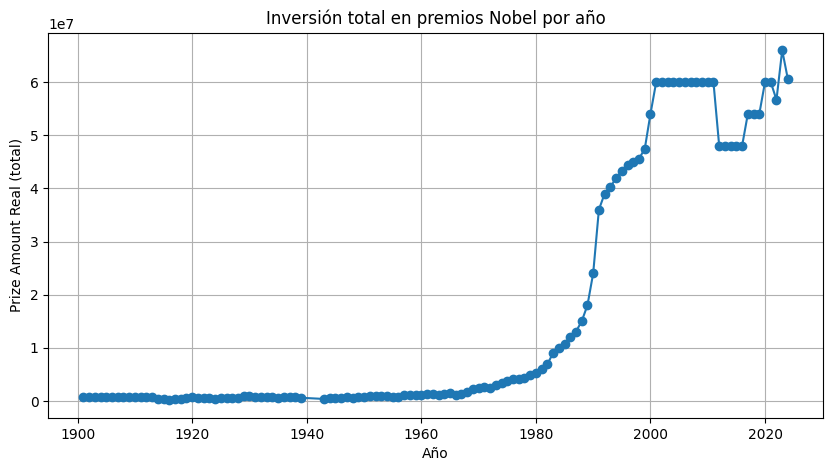

In [44]:
import matplotlib.pyplot as plt

investment_per_year = df.groupby('year')['prize_amount_real'].sum()
investment_per_year.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Inversión total en premios Nobel por año')
plt.ylabel('Prize Amount Real (total)')
plt.xlabel('Año')
plt.grid()
plt.show()

La tendencia de la inversión total en premios Nobel por año es ascendente, especialmente a partir de los años 1980.

In [45]:
award_counts = df.groupby(['laureate_id', 'full_name']).size().reset_index(name='num_premios')
top_repeat = award_counts[award_counts['num_premios'] > 2].sort_values('num_premios', ascending=False).head(5)

print("Top 5 laureados con más de dos premios:")
print(top_repeat)


Top 5 laureados con más de dos premios:
Empty DataFrame
Columns: [laureate_id, full_name, num_premios]
Index: []


Nadie ha ganado mas de dos premios Nobel

In [53]:

category_count = df['category'].value_counts()
top_category = category_count.head(1)
cat, n = top_category.index[0], top_category.iloc[0]
print(f"Categoría con más premios: {cat} ({n} premios)")


category_money = df.groupby('category')['prize_amount_real'].sum().sort_values(ascending=False)
cat_money, amount = category_money.head(1).index[0], category_money.head(1).iloc[0]
print(f"Categoría que más dinero ha entregado: {cat_money} ({amount:,.2f})")


Categoría con más premios: Physiology or Medicine (229 premios)
Categoría que más dinero ha entregado: Literature (340,157,420.00)
